In [ ]:
!pip install rasterio geopandas xgboost scikit-learn matplotlib seaborn pandas numpy plotly -q
print('All packages installed ✓')

All packages installed ✓


In [ ]:
import os

BASE_DIR = '/content/drive/MyDrive/PhytoLB'

# Use exact folder names as they appear in Drive
TREE_OCCURRENCE = BASE_DIR + '/dwca-tree_lebanon-v1.0/occurrence.txt'
WORLDCLIM_DIR   = BASE_DIR + '/wc2.1_10m_bio'
GRIIS_DIR       = BASE_DIR + '/dwca-griis-lebanon-v1.1'

# Verify paths exist
import os
print(os.path.exists(TREE_OCCURRENCE))
print(os.path.exists(WORLDCLIM_DIR))


Mounted at /content/drive
True
True


In [ ]:
import os

print('=== Tree Lebanon Dataset ===')
tree_dir = os.path.join(BASE_DIR, 'dwca-tree-lebanon-v1.0')
if os.path.exists(tree_dir):
    for f in os.listdir(tree_dir):
        print(f'  {f}')

print()
print('=== WorldClim Files ===')
if os.path.exists(WORLDCLIM_DIR):
    files = [f for f in os.listdir(WORLDCLIM_DIR) if f.endswith('.tif')]
    print(f'  Found {len(files)} .tif files')
    for f in sorted(files)[:5]:
        print(f'  {f}')
    print('  ...')

=== Tree Lebanon Dataset ===

=== WorldClim Files ===
  Found 19 .tif files
  wc2.1_10m_bio_1.tif
  wc2.1_10m_bio_10.tif
  wc2.1_10m_bio_11.tif
  wc2.1_10m_bio_12.tif
  wc2.1_10m_bio_13.tif
  ...


In [ ]:
import pandas as pd
import numpy as np

try:
    df_raw = pd.read_csv(TREE_OCCURRENCE, sep='\t', on_bad_lines='skip', low_memory=False)
    print(f'Loaded {len(df_raw):,} records')
    print(f'Columns: {list(df_raw.columns)}')
    df_raw.head()
except Exception as e:
    print(f'Error: {e}')
    # Try CSV format
    df_raw = pd.read_csv(TREE_OCCURRENCE.replace('.txt', '.csv'), low_memory=False)
    print(f'Loaded CSV: {len(df_raw):,} records')

Loaded 13,748 records
Columns: ['id', 'basisOfRecord', 'occurrenceID', 'individualCount', 'occurrenceStatus', 'eventDate', 'continent', 'country', 'countryCode', 'locality', 'decimalLatitude', 'decimalLongitude', 'geodeticDatum', 'scientificName', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'specificEpithet', 'taxonRank']


In [ ]:
lat_col = 'decimalLatitude'
lon_col = 'decimalLongitude'
species_col = 'scientificName'

cols_needed = [lat_col, lon_col, species_col]
available = [c for c in cols_needed if c in df_raw.columns]
print(f'Available needed columns: {available}')

df = df_raw[available].copy()

df = df.dropna(subset=[lat_col, lon_col, species_col])

df = df[
    (df[lat_col] >= 33.05) & (df[lat_col] <= 34.69) &
    (df[lon_col] >= 35.10) & (df[lon_col] <= 36.62)
]

print(f'After filtering to Lebanon: {len(df):,} records')
print(f'Unique species: {df[species_col].nunique()}')
print(df[species_col].value_counts().head(10))

Available needed columns: ['decimalLatitude', 'decimalLongitude', 'scientificName']
After filtering to Lebanon: 13,748 records
Unique species: 27
scientificName
Quercus infectoria boissieri     2084
Quercus coccifera calliprinos    1905
Juniperus excelsa                1443
Juniperus drupacea               1014
Ceratonia siliqua                 787
Quercus ithaburensis              638
Cedrus libani                     594
Abies cilicica                    576
Styrax officinalis                564
Arbutus andrachne                 535
Name: count, dtype: int64


In [ ]:
import rasterio
import os

def extract_bioclim(lat, lon, worldclim_dir):
    """Extract 19 bioclimatic variables for a given lat/lon."""
    values = {}
    tif_files = sorted([f for f in os.listdir(worldclim_dir) if f.endswith('.tif')])

    for tif_file in tif_files:
        var_name = tif_file.replace('wc2.1_10m_', '').replace('.tif', '')  # e.g. bio_1
        tif_path = os.path.join(worldclim_dir, tif_file)

        try:
            with rasterio.open(tif_path) as src:
                row, col = src.index(lon, lat)
                val = src.read(1)[row, col]
                if val == src.nodata:
                    val = np.nan
                values[var_name] = float(val)
        except Exception:
            values[var_name] = np.nan

    return values

# Test on Beirut coordinates
beirut_lat, beirut_lon = 33.8886, 35.4955
test_values = extract_bioclim(beirut_lat, beirut_lon, WORLDCLIM_DIR)
print(f'Bioclim values for Beirut:')
for k, v in list(test_values.items())[:5]:
    print(f'  {k}: {v}')

Bioclim values for Beirut:
  bio_1: 20.08967399597168
  bio_10: 26.20941925048828
  bio_11: 14.108695983886719
  bio_12: 813.0
  bio_13: 191.0


In [ ]:
from tqdm import tqdm

MAX_SAMPLES = 5000 
if len(df) > MAX_SAMPLES:
    df_sample = df.sample(MAX_SAMPLES, random_state=42)
else:
    df_sample = df.copy()

print(f'Extracting bioclim features for {len(df_sample):,} records...')

test_list = []
for _, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
    feats = extract_bioclim(row[lat_col], row[lon_col], WORLDCLIM_DIR)
    feats['species'] = row[species_col]
    feats['latitude'] = row[lat_col]
    feats['longitude'] = row[lon_col]
    test_list.append(feats)

test_df = pd.DataFrame(test_list)
print(f'Feature matrix shape: {test_df.shape}')
test_df.head()

Extracting bioclim features for 5,000 records...


100%|██████████| 5000/5000 [1:13:58<00:00,  1.13it/s]

Feature matrix shape: (5000, 22)


,bio_1,bio_10,bio_11,bio_12,bio_13,bio_14,bio_15,bio_16,bio_17,bio_18,...,bio_3,bio_4,bio_5,bio_6,bio_7,bio_8,bio_9,species,latitude,longitude
0,12.723865,20.986000,4.217375,654.0,139.0,0.0,92.442665,370.0,3.0,4.0,...,42.440319,701.593384,30.202749,-1.00200,31.204750,4.217375,20.969334,Juniperus excelsa,34.272820,36.208886
1,10.665334,18.402874,2.585542,974.0,215.0,0.0,97.035912,565.0,4.0,4.0,...,40.573444,658.841309,27.159500,-2.07750,29.237000,2.736417,18.247334,Quercus infectoria boissieri,34.101026,35.860330
2,17.330229,25.024000,8.957958,771.0,150.0,1.0,89.109909,423.0,6.0,8.0,...,39.390400,664.263672,31.969000,3.92600,28.042999,8.957958,24.733376,Quercus ithaburensis,34.610606,36.249905
3,14.195636,21.731874,6.345666,901.0,182.0,1.0,90.802452,499.0,6.0,9.0,...,40.042355,641.330994,29.133751,1.50025,27.633501,6.345666,21.531834,Arbutus andrachne,34.420000,36.032600
4,11.153177,19.165417,2.935375,747.0,153.0,0.0,90.256210,414.0,5.0,5.0,...,40.917885,679.128174,27.974501,-2.01875,29.993250,2.935375,19.049250,Acer monspessulanum microphyllum,34.464369,36.222756


In [ ]:
print(f'Extracting bioclim features for {len(df):,} records...')

features_list = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    feats = extract_bioclim(row[lat_col], row[lon_col], WORLDCLIM_DIR)
    feats['species'] = row[species_col]
    feats['latitude'] = row[lat_col]
    feats['longitude'] = row[lon_col]
    features_list.append(feats)

features_df = pd.DataFrame(features_list)
print(f'Feature matrix shape: {features_df.shape}')

Extracting bioclim features for 13,748 records...


100%|██████████| 13748/13748 [3:26:25<00:00,  1.11it/s]


Feature matrix shape: (13748, 22)


In [ ]:
print(len(features_df))  

13748


In [ ]:
SAVE_PATH = '/content/drive/MyDrive/PhytoLB/features_df.csv'

features_df.to_csv(SAVE_PATH, index=False)
print(f'✅ Saved features_df to: {SAVE_PATH}')
print(f'   Shape: {features_df.shape}')

✅ Saved features_df to: /content/drive/MyDrive/PhytoLB/features_df.csv
   Shape: (13748, 22)


In [ ]:
SAVE_DIR = '/content/drive/MyDrive/PhytoLB'

In [ ]:
import numpy as np

np.random.seed(42)
os.makedirs(f'{SAVE_DIR}/figures', exist_ok=True)
os.makedirs(f'{SAVE_DIR}/models',  exist_ok=True)

all_species   = features_df['species'].unique()
presence_rows = []
absence_rows  = []

print(f'Generating per-species pseudo-absences for {len(all_species)} species...\n')

for species_name in all_species:
    sp_df = features_df[features_df['species'] == species_name].copy()
    n     = len(sp_df)

    # Presences
    sp_df['label'] = 1
    presence_rows.append(sp_df)

    oversample  = int(n * 1.3)
    lats        = np.random.uniform(33.05, 34.69, oversample)
    lons        = np.random.uniform(35.10, 36.62, oversample)

    sp_absences = []
    for lat, lon in zip(lats, lons):
        feats = extract_bioclim(lat, lon, WORLDCLIM_DIR)
        if any(v is None or (isinstance(v, float) and np.isnan(v))
               for v in feats.values()):
            continue                         
        feats['species']   = species_name   
        feats['latitude']  = lat
        feats['longitude'] = lon
        feats['label']     = 0
        sp_absences.append(feats)
        if len(sp_absences) == n:
            break                           

    absence_rows.append(pd.DataFrame(sp_absences))
    print(f'  {species_name:<40} presences={n:4d}  absences={len(sp_absences):4d}')

# Combine presences + absences
presence_df = pd.concat(presence_rows, ignore_index=True)
absence_df  = pd.concat(absence_rows,  ignore_index=True)
full_df     = pd.concat([presence_df, absence_df], ignore_index=True).dropna()

print(f'\nFull dataset : {len(full_df):,} samples')
print(f'  Presences  : {full_df["label"].sum():,}')
print(f'  Absences   : {(full_df["label"] == 0).sum():,}')
print(f'  Balance    : {full_df["label"].mean():.3f}  (1.0 = perfectly balanced)')

bal = full_df.groupby('species')['label'].agg(['sum', 'count'])
bal['balance'] = (bal['sum'] / bal['count']).round(3)
print(f'\nPer-species balance:\n{bal.to_string()}')

full_df.to_csv(f'{SAVE_DIR}/full_df.csv', index=False)
print(f'\n✅ Saved full_df → {SAVE_DIR}/full_df.csv  shape={full_df.shape}')

Generating per-species pseudo-absences for 27 species...

  Crataegus azarolus                       presences= 249  absences= 249
  Styrax officinalis                       presences= 564  absences= 564
  Sorbus torminalis                        presences= 188  absences= 188
  Pyrus syriaca                            presences= 335  absences= 335
  Pinus pinea                              presences= 463  absences= 463
  Malus trilobata                          presences=  55  absences=  55
  Quercus look                             presences= 113  absences= 113
  Laurus nobilis                           presences= 129  absences= 129
  Quercus kotschyana                       presences= 122  absences= 122
  Juniperus excelsa                        presences=1443  absences=1443
  Juniperus drupacea                       presences=1014  absences=1014
  Quercus ithaburensis                     presences= 638  absences= 638
  Quercus infectoria boissieri             presences=2084  absence

In [ ]:
CAP = int(features_df['species'].value_counts().median())
print(f'Median species count : {CAP}')
print(f'Before cap : {len(features_df):,} records')

features_df = (
    features_df
    .groupby('species', group_keys=False)
    .apply(lambda x: x.sample(min(len(x), CAP), random_state=42))
    .reset_index(drop=True)
)

print(f'After cap  : {len(features_df):,} records')
print(f'\nPer-species counts after capping:')
print(features_df['species'].value_counts().to_string())

Median species count : 322
Before cap : 13,748 records
After cap  : 6,648 records

Per-species counts after capping:
species
Abies cilicica                      322
Arbutus andrachne                   322
Cedrus libani                       322
Cupressus sempervirens              322
Ceratonia siliqua                   322
Cercis siliquastrum                 322
Styrax officinalis                  322
Pinus pinea                         322
Pyrus syriaca                       322
Juniperus excelsa                   322
Juniperus drupacea                  322
Quercus infectoria boissieri        322
Quercus ithaburensis                322
Quercus coccifera calliprinos       322
Acer obtusifolium                   293
Acer monspessulanum microphyllum    250
Crataegus azarolus                  249
Acer hyrcanum tauricolum            214
Quercus cerris                      193
Sorbus torminalis                   188
Fraxinus ornus                      138
Laurus nobilis                     

/tmp/ipykernel_646/3065905303.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), CAP), random_state=42))


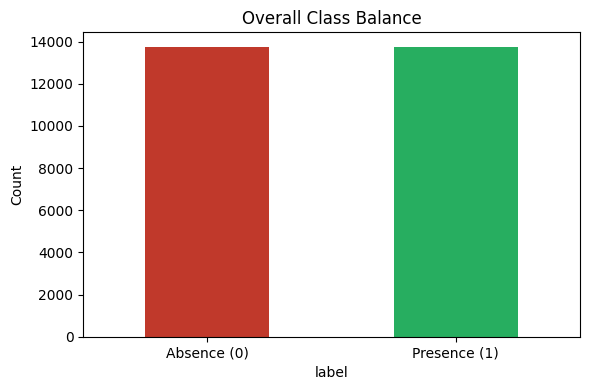

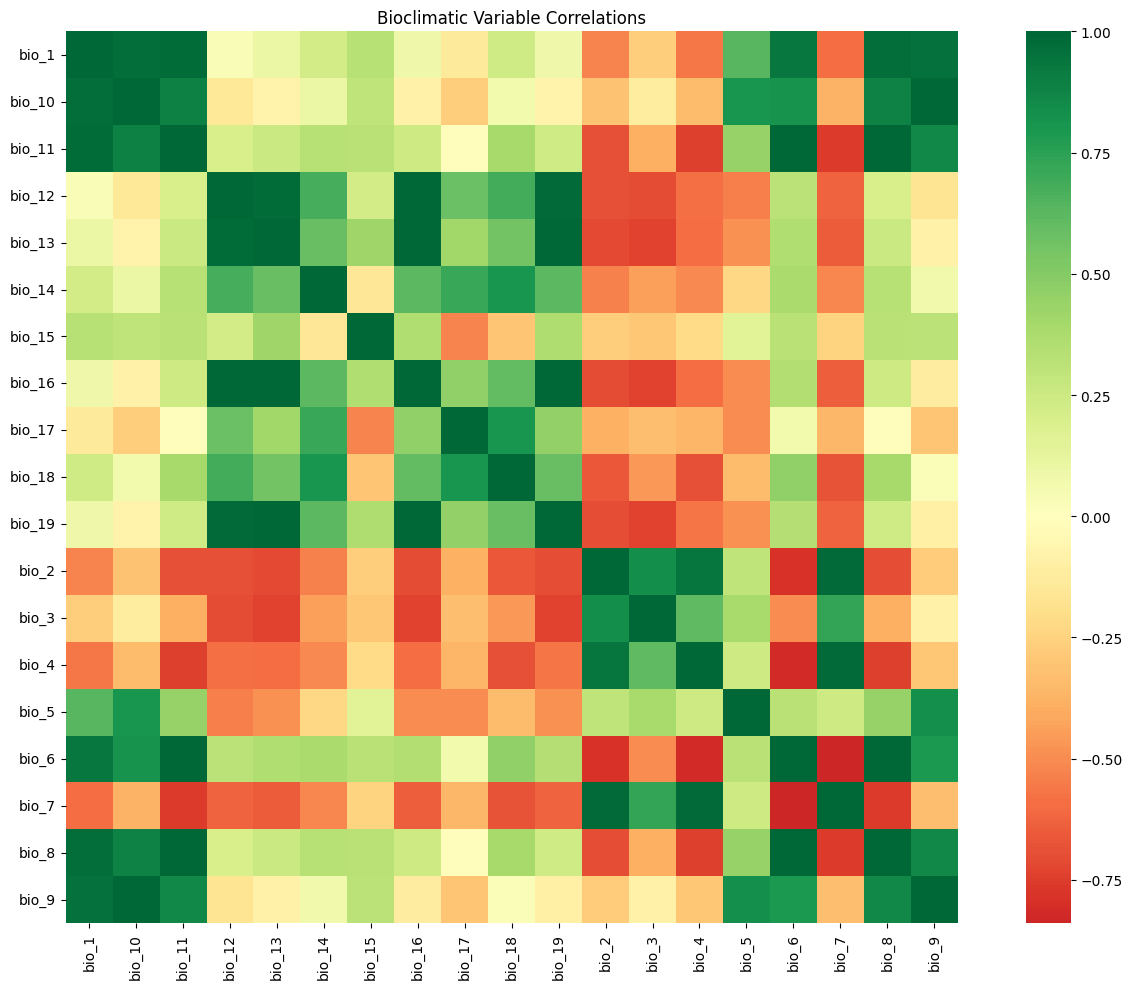

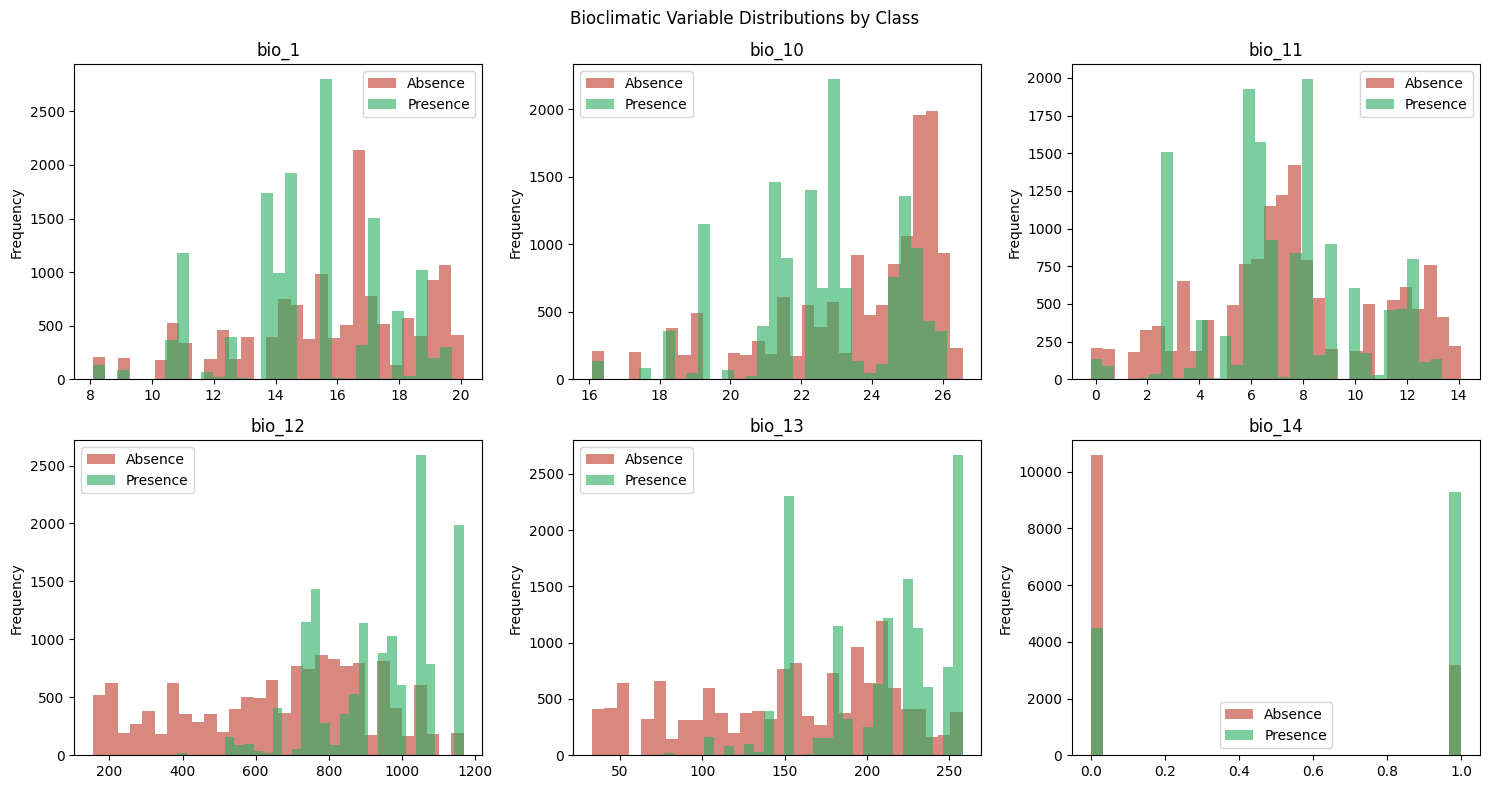

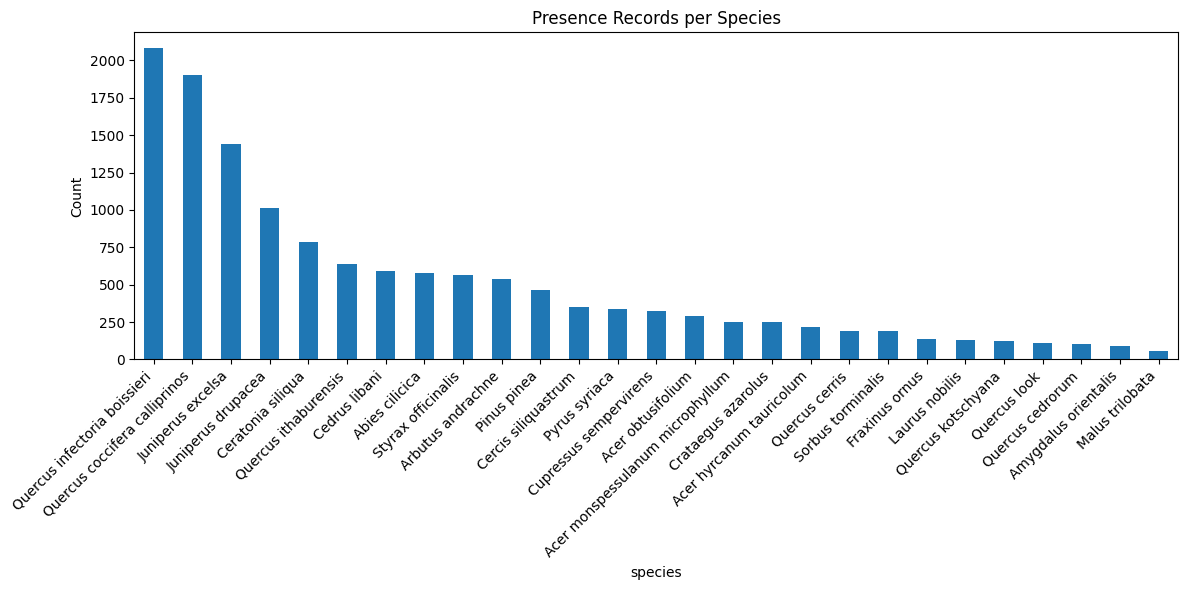

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

bio_cols = sorted([c for c in full_df.columns if c.startswith('bio_')])

plt.figure(figsize=(6, 4))
full_df['label'].value_counts().plot(kind='bar',
    color=['#c0392b', '#27ae60'])
plt.xticks([0, 1], ['Absence (0)', 'Presence (1)'], rotation=0)
plt.title('Overall Class Balance')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/figures/class_balance.png', dpi=150)
plt.show()

plt.figure(figsize=(14, 10))
sns.heatmap(full_df[bio_cols].corr(), cmap='RdYlGn', center=0,
            annot=False, square=True)
plt.title('Bioclimatic Variable Correlations')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/figures/correlation_heatmap.png', dpi=150)
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, var in zip(axes.flat, bio_cols[:6]):
    for label, color, name in [
        (0, '#c0392b', 'Absence'),
        (1, '#27ae60', 'Presence')
    ]:
        full_df[full_df['label'] == label][var].plot(
            kind='hist', alpha=0.6, bins=30,
            ax=ax, color=color, label=name)
    ax.set_title(var)
    ax.legend()
plt.suptitle('Bioclimatic Variable Distributions by Class')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/figures/variable_distributions.png', dpi=150)
plt.show()

plt.figure(figsize=(12, 6))
full_df[full_df['label'] == 1]['species'].value_counts().plot(kind='bar')
plt.title('Presence Records per Species')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/figures/species_counts.png', dpi=150)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import MinMaxScaler, LabelEncoder
from sklearn.impute           import SimpleImputer

le = LabelEncoder()
full_df['species_encoded'] = le.fit_transform(full_df['species'])

print('Species encoding:')
for code, name in enumerate(le.classes_):
    print(f'  {code:2d} → {name}')
    
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = full_df[bio_cols].corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.90)]
bio_cols_reduced = [c for c in bio_cols if c not in to_drop]

print(f'Original features  : {len(bio_cols)}')
print(f'Dropped (corr>0.90): {len(to_drop)} → {to_drop}')
print(f'Remaining bioclim  : {len(bio_cols_reduced)}')

feature_cols = bio_cols_reduced + ['species_encoded']

X = full_df[feature_cols].copy()
y = full_df['label'].copy()

strat_key = full_df['species'] + '_' + full_df['label'].astype(str)

X_train, X_temp, y_train, y_temp, sk_train, sk_temp = train_test_split(
    X, y, strat_key,
    test_size=0.30,
    stratify=strat_key,
    random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=sk_temp,
    random_state=42
)

print(f'\nSplit sizes:')
print(f'  Train : {len(X_train):,}  ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Val   : {len(X_val):,}   ({len(X_val)/len(X)*100:.1f}%)')
print(f'  Test  : {len(X_test):,}   ({len(X_test)/len(X)*100:.1f}%)')

for split_name, ys in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f'  {split_name} balance: {ys.mean():.3f}')

imputer = SimpleImputer(strategy='mean')
X_train_imp = imputer.fit_transform(X_train)
X_val_imp   = imputer.transform(X_val)
X_test_imp  = imputer.transform(X_test)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled   = scaler.transform(X_val_imp)
X_test_scaled  = scaler.transform(X_test_imp)

print(f'\n✅ Preprocessing done — no data leakage')
print(f'   Train shape : {X_train_scaled.shape}')
print(f'   Features    : {len(bio_cols)} bioclim + 1 species = {len(feature_cols)}')

Species encoding:
   0 → Abies cilicica
   1 → Acer hyrcanum tauricolum
   2 → Acer monspessulanum microphyllum
   3 → Acer obtusifolium
   4 → Amygdalus orientalis
   5 → Arbutus andrachne
   6 → Cedrus libani
   7 → Ceratonia siliqua
   8 → Cercis siliquastrum
   9 → Crataegus azarolus
  10 → Cupressus sempervirens
  11 → Fraxinus ornus
  12 → Juniperus drupacea
  13 → Juniperus excelsa
  14 → Laurus nobilis
  15 → Malus trilobata
  16 → Pinus pinea
  17 → Pyrus syriaca
  18 → Quercus cedrorum
  19 → Quercus cerris
  20 → Quercus coccifera calliprinos
  21 → Quercus infectoria boissieri
  22 → Quercus ithaburensis
  23 → Quercus kotschyana
  24 → Quercus look
  25 → Sorbus torminalis
  26 → Styrax officinalis
Original features  : 19
Dropped (corr>0.90): 10 → ['bio_10', 'bio_11', 'bio_13', 'bio_16', 'bio_19', 'bio_4', 'bio_6', 'bio_7', 'bio_8', 'bio_9']
Remaining bioclim  : 9

Split sizes:
  Train : 19,245  (70.0%)
  Val   : 4,124   (15.0%)
  Test  : 4,125   (15.0%)
  Train balance: 0

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics  import (accuracy_score, roc_auc_score, f1_score,
                               classification_report, cohen_kappa_score)
import joblib

print('Training Random Forest...')
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf.fit(X_train_scaled, y_train)

rf_val_auc = roc_auc_score(y_val, rf.predict_proba(X_val_scaled)[:, 1])
print(f'Val AUC : {rf_val_auc:.4f}')

rf_pred  = rf.predict(X_test_scaled)
rf_prob  = rf.predict_proba(X_test_scaled)[:, 1]
rf_acc   = accuracy_score(y_test, rf_pred)
rf_auc   = roc_auc_score(y_test, rf_prob)
rf_f1    = f1_score(y_test, rf_pred, average='macro')
rf_kappa = cohen_kappa_score(y_test, rf_pred)

print(f'\nRandom Forest — Test Results:')
print(f'  Accuracy    : {rf_acc:.4f}')
print(f'  AUC-ROC     : {rf_auc:.4f}')
print(f'  Macro F1    : {rf_f1:.4f}')
print(f'  Cohen Kappa : {rf_kappa:.4f}')
print()
print(classification_report(y_test, rf_pred,
      target_names=['Absence', 'Presence']))

Training Random Forest...
Val AUC : 0.9379

Random Forest — Test Results:
  Accuracy    : 0.8795
  AUC-ROC     : 0.9359
  Macro F1    : 0.8792
  Cohen Kappa : 0.7590

              precision    recall  f1-score   support

     Absence       0.92      0.83      0.87      2063
    Presence       0.85      0.93      0.89      2062

    accuracy                           0.88      4125
   macro avg       0.88      0.88      0.88      4125
weighted avg       0.88      0.88      0.88      4125



In [ ]:
import os
os.makedirs(f'{SAVE_DIR}/models/v3', exist_ok=True)

joblib.dump(rf, f'{SAVE_DIR}/models/v3/rf_model.pkl')
print('✅ Random Forest saved')

✅ Random Forest saved


In [ ]:
from xgboost              import XGBClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth'        : [5, 7, 9],
    'learning_rate'    : [0.05, 0.1, 0.2],
    'n_estimators'     : [200, 300, 500],
    'subsample'        : [0.8, 1.0],
    'colsample_bytree' : [0.8, 1.0],
}

print('Tuning XGBoost — 5-fold CV on training set...')
xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
grid_search = GridSearchCV(
    xgb_base, param_grid,
    cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train_scaled, y_train)

print(f'\nBest params : {grid_search.best_params_}')
print(f'Best CV AUC : {grid_search.best_score_:.4f}')

xgb = grid_search.best_estimator_
xgb_val_auc = roc_auc_score(y_val, xgb.predict_proba(X_val_scaled)[:, 1])
print(f'Val AUC     : {xgb_val_auc:.4f}')

xgb_pred  = xgb.predict(X_test_scaled)
xgb_prob  = xgb.predict_proba(X_test_scaled)[:, 1]
xgb_acc   = accuracy_score(y_test, xgb_pred)
xgb_auc   = roc_auc_score(y_test, xgb_prob)
xgb_f1    = f1_score(y_test, xgb_pred, average='macro')
xgb_kappa = cohen_kappa_score(y_test, xgb_pred)

print(f'\nXGBoost — Test Results:')
print(f'  Accuracy    : {xgb_acc:.4f}')
print(f'  AUC-ROC     : {xgb_auc:.4f}')
print(f'  Macro F1    : {xgb_f1:.4f}')
print(f'  Cohen Kappa : {xgb_kappa:.4f}')
print()
print(classification_report(y_test, xgb_pred,
      target_names=['Absence', 'Presence']))

joblib.dump(xgb,     f'{SAVE_DIR}/models/v3/xgb_model.pkl')
joblib.dump(imputer, f'{SAVE_DIR}/models/v3/imputer.pkl')
joblib.dump(scaler,  f'{SAVE_DIR}/models/v3/scaler.pkl')
joblib.dump(le,      f'{SAVE_DIR}/models/v3/label_encoder.pkl')
print('✅ XGBoost + preprocessing objects saved')

Tuning XGBoost — 5-fold CV on training set...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best params : {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 500, 'subsample': 1.0}
Best CV AUC : 0.9469
Val AUC     : 0.9434

XGBoost — Test Results:
  Accuracy    : 0.8793
  AUC-ROC     : 0.9405
  Macro F1    : 0.8789
  Cohen Kappa : 0.7586

              precision    recall  f1-score   support

     Absence       0.92      0.83      0.87      2063
    Presence       0.84      0.93      0.89      2062

    accuracy                           0.88      4125
   macro avg       0.88      0.88      0.88      4125
weighted avg       0.88      0.88      0.88      4125

✅ XGBoost + preprocessing objects saved


In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.base import clone

print('Training Ensemble (RF + XGBoost)...')

ensemble = VotingClassifier(
    estimators=[
        ('rf',  clone(rf).fit(X_train_scaled, y_train)),
        ('xgb', clone(xgb).fit(X_train_scaled, y_train)),
    ],
    voting='soft'   
)
ensemble.fit(X_train_scaled, y_train)

ens_pred  = ensemble.predict(X_test_scaled)
ens_prob  = ensemble.predict_proba(X_test_scaled)[:, 1]
ens_acc   = accuracy_score(y_test, ens_pred)
ens_auc   = roc_auc_score(y_test, ens_prob)
ens_f1    = f1_score(y_test, ens_pred, average='macro')
ens_kappa = cohen_kappa_score(y_test, ens_pred)

print(f'\nEnsemble — Test Results:')
print(f'  Accuracy    : {ens_acc:.4f}')
print(f'  AUC-ROC     : {ens_auc:.4f}')
print(f'  Macro F1    : {ens_f1:.4f}')
print(f'  Cohen Kappa : {ens_kappa:.4f}')

joblib.dump(ensemble, f'{SAVE_DIR}/models/v3/ensemble_model.pkl')
print('✅ Ensemble saved')

Training Ensemble (RF + XGBoost)...

Ensemble — Test Results:
  Accuracy    : 0.8785
  AUC-ROC     : 0.9402
  Macro F1    : 0.8783
  Cohen Kappa : 0.7571
✅ Ensemble saved


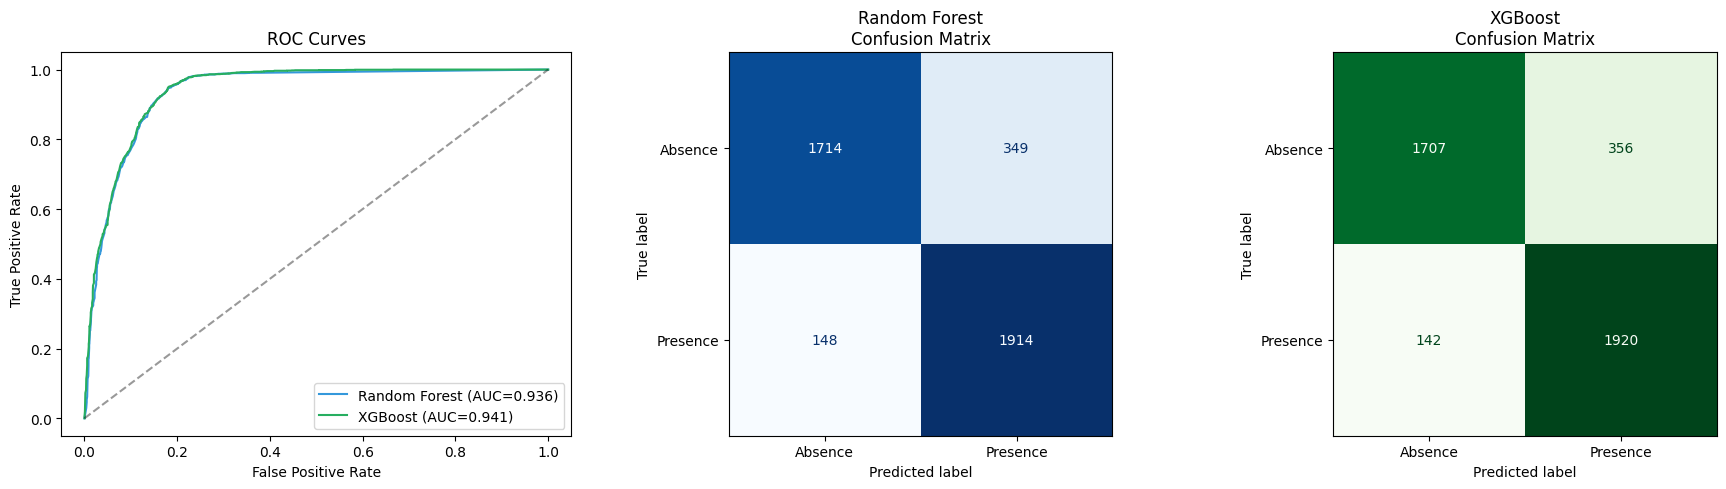

In [ ]:
from sklearn.metrics import roc_curve, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
for prob, label, color in [
    (rf_prob,  'Random Forest', '#3498db'),
    (xgb_prob, 'XGBoost',       '#27ae60')
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=color, label=f'{label} (AUC={auc_val:.3f})')
ax.plot([0,1], [0,1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend()

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred,
    display_labels=['Absence', 'Presence'],
    ax=axes[1], colorbar=False, cmap='Blues'
)
axes[1].set_title('Random Forest\nConfusion Matrix')

ConfusionMatrixDisplay.from_predictions(
    y_test, xgb_pred,
    display_labels=['Absence', 'Presence'],
    ax=axes[2], colorbar=False, cmap='Greens'
)
axes[2].set_title('XGBoost\nConfusion Matrix')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/figures/v3_roc_confusion.png', dpi=150)
plt.show()


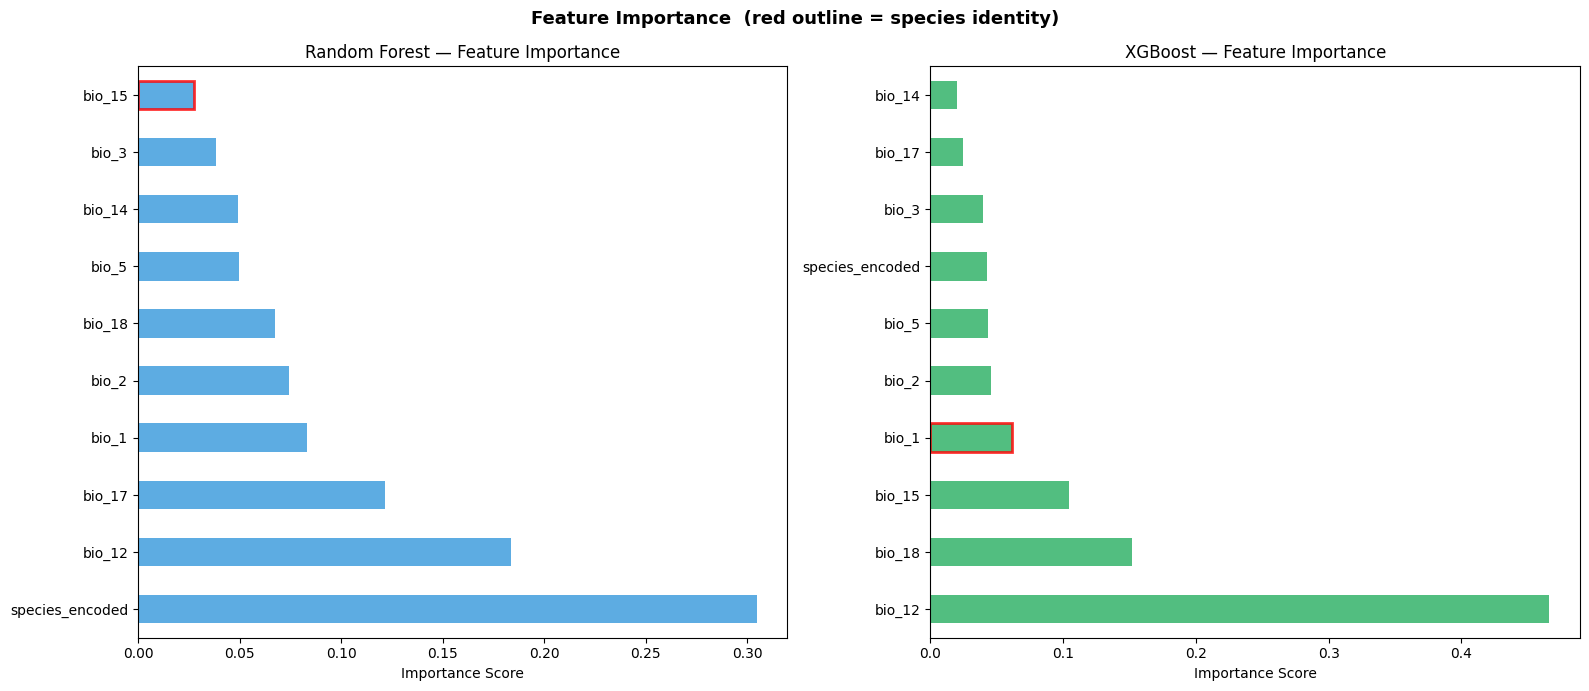

Top 5 features (XGBoost):
bio_12    0.466170
bio_18    0.151802
bio_15    0.104248
bio_1     0.061696
bio_2     0.045919
dtype: float32


In [ ]:
feature_names = feature_cols  # already = bio_cols_reduced + ['species_encoded']

xgb_imp = pd.Series(xgb.feature_importances_,
                    index=feature_names).sort_values(ascending=False)
rf_imp  = pd.Series(rf.feature_importances_,
                    index=feature_names).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, imp, title, color in [
    (axes[0], rf_imp,  'Random Forest', '#3498db'),
    (axes[1], xgb_imp, 'XGBoost',       '#27ae60'),
]:
    imp.plot(kind='barh', ax=ax, color=color, alpha=0.8)
    ax.set_title(f'{title} — Feature Importance')
    ax.set_xlabel('Importance Score')
    # Highlight the species_encoded bar in red
    for patch, name in zip(ax.patches, imp.index[::-1]):
        if name == 'species_encoded':
            patch.set_edgecolor('red')
            patch.set_linewidth(2)

plt.suptitle('Feature Importance  (red outline = species identity)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/figures/v3_feature_importance.png', dpi=150)
plt.show()

print('Top 5 features (XGBoost):')
print(xgb_imp.head())

In [ ]:
lebanese_cities = {
    'Beirut'   : (33.8886, 35.4955),
    'Tripoli'  : (34.4333, 35.8333),
    'Sidon'    : (33.5571, 35.3729),
    'Tyre'     : (33.2705, 35.2037),
    'Zahle'    : (33.8464, 35.9017),
    'Baalbek'  : (34.0042, 36.2097),
    'Bcharre'  : (34.2522, 36.0139),
    'Faraya'   : (34.0922, 35.8789),
    'Byblos'   : (34.1236, 35.6513),
    'Nabatieh' : (33.3778, 35.4836),
}

target_species = [s for s in le.classes_ if s != 'pseudo_absence']

print(f'{len(lebanese_cities)} cities × {len(target_species)} species '
      f'= {len(lebanese_cities)*len(target_species)} predictions\n')

print('Extracting bioclim for cities...')
city_bioclim = {}
for city, (lat, lon) in lebanese_cities.items():
    city_bioclim[city] = extract_bioclim(lat, lon, WORLDCLIM_DIR)
    print(f'  {city} ✓')

rows = []
for city in lebanese_cities:
    for species_name in target_species:
        row = dict(city_bioclim[city])
        row['species_encoded'] = int(le.transform([species_name])[0])
        row['city']            = city
        row['species']         = species_name
        rows.append(row)

pred_df = pd.DataFrame(rows)

X_pred        = pred_df[feature_cols].copy()
X_pred_imp    = imputer.transform(X_pred)
X_pred_scaled = scaler.transform(X_pred_imp)

pred_df['rf_suitability']  = rf.predict_proba(X_pred_scaled)[:, 1]
pred_df['xgb_suitability'] = xgb.predict_proba(X_pred_scaled)[:, 1]
pred_df['rf_suitable']     = (pred_df['rf_suitability']  >= 0.5).astype(int)
pred_df['xgb_suitable']    = (pred_df['xgb_suitability'] >= 0.5).astype(int)

pred_df.to_csv(f'{SAVE_DIR}/models/v3/city_species_suitability.csv', index=False)
print('\n✅ Saved city × species suitability table')

summary = pred_df.groupby('city').agg(
    rf_suitable_count  = ('rf_suitable',     'sum'),
    xgb_suitable_count = ('xgb_suitable',    'sum'),
    rf_mean_score      = ('rf_suitability',  'mean'),
    xgb_mean_score     = ('xgb_suitability', 'mean'),
).reset_index()

print(f'\nSuitable species per city (out of {len(target_species)}):')
print(summary.sort_values('xgb_suitable_count', ascending=False).to_string(index=False))

10 cities × 27 species = 270 predictions

Extracting bioclim for cities...
  Beirut ✓
  Tripoli ✓
  Sidon ✓
  Tyre ✓
  Zahle ✓
  Baalbek ✓
  Bcharre ✓
  Faraya ✓
  Byblos ✓
  Nabatieh ✓

✅ Saved city × species suitability table

Suitable species per city (out of 27):
    city  rf_suitable_count  xgb_suitable_count  rf_mean_score  xgb_mean_score
  Faraya                  6                   7       0.370032        0.389294
 Bcharre                  5                   6       0.248680        0.265384
 Baalbek                  4                   4       0.155125        0.148725
   Sidon                  3                   4       0.159814        0.168114
  Byblos                  5                   3       0.180347        0.153335
   Zahle                  1                   2       0.128039        0.169337
 Tripoli                  1                   1       0.027092        0.031423
  Beirut                  0                   0       0.000000        0.000801
Nabatieh             